In [7]:
#import giggle_my_version as giggle
import numpy as np 
import matplotlib.pyplot as plt

import math
#from scipy import ndimage as ndimage
#import disk_ecc_spiral as disk
#import disk_ecc as kevindisk
#import disk_ecc_spiral_pp as proto
#from astropy import units as u
#from astropy.constants import G, sigma_sb, k_B, m_p
from astropy.io import fits
import bettermoments as bm
import matplotlib.gridspec as gridspec


from astropy.io import fits
from astropy.wcs import WCS
from matplotlib.patches import Ellipse

import astropy.units as u
from astropy.wcs.utils import proj_plane_pixel_scales
import cmcrameri.cm as cmc
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

import matplotlib.transforms as mtransforms

import cmocean
#from scipy.interpolate import LinearNDInterpolator as interpnd

In [8]:
kep_m0 = fits.open('../dmr_plots/49Ceti_resid_map_4-18_M0.fits')
kep_m0_im = kep_m0["PRIMARY"].data

kep_m1 = fits.open('../dmr_plots/49Ceti_resid_map_4-18_M1.fits')
kep_m1_im = kep_m1["PRIMARY"].data

spiralm1_m0 = fits.open('../dmr_plots/49Ceti_resid_spiralm1_4-18_M0.fits')
spiralm1_m0_im = spiralm1_m0["PRIMARY"].data

spiralm1_m1 = fits.open('../dmr_plots/49Ceti_resid_spiralm1_4-18_M1.fits')
spiralm1_m1_im = spiralm1_m1["PRIMARY"].data

spiralm2_m0 = fits.open('../dmr_plots/49Ceti_resid_spiral_m2_4-18_M0.fits')
spiralm2_m0_im = spiralm2_m0["PRIMARY"].data

spiralm2_m1 = fits.open('../dmr_plots/49Ceti_resid_spiral_m2_4-18_M1.fits')
spiralm2_m1_im = spiralm2_m1["PRIMARY"].data

In [9]:
spiralm2_m0["PRIMARY"].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  512                                                  
NAXIS2  =                  512                                                  
BMAJ    =    9.28980589379E-05                                                  
BMIN    =    7.74017098593E-05                                                  
BPA     =   -84.72030639650001                                                  
BUNIT   = 'JY/BEAM m/s'                                                         
CTYPE1  = 'RA---SIN'                                                            
CRVAL1  =                  0.0                                                  
CDELT1  =   -1.22222229095E-05                                                  
CRPIX1  =                257

In [10]:
9.28980589379E-05*3600

0.33443301217644

In [11]:
7.74017098593E-05*3600

0.27864615549348

In [12]:
def wcs_extent(image, wcs):
    nx, ny = image.shape
    cx, cy = nx / 2.0, ny / 2.0
    ctr = wcs.pixel_to_world(cx, cy)
    ra_ctr = ctr.ra
    dec_ctr = ctr.dec
    left = wcs.pixel_to_world(0, cy).ra
    right = wcs.pixel_to_world(nx - 1, cy).ra
    bot = wcs.pixel_to_world(cx, 0).dec
    top = wcs.pixel_to_world(cx, ny - 1).dec
    ra_scale = np.cos(dec_ctr.rad) * 3600.0
    return [
        (left - ra_ctr).deg * ra_scale,
        (right - ra_ctr).deg * ra_scale,
        (bot - dec_ctr).deg * 3600.0,
        (top - dec_ctr).deg * 3600.0,
    ]

In [13]:
'''
path = '../dmr_plots/49Ceti_resid_spiral_m2_4-18.fits'
data, velax = bm.load_cube(path)
rms = bm.estimate_RMS(data=data, N=1)
threshold_mask = bm.get_threshold_mask(data=data,
                                       clip=3,
                                       smooth_threshold_mask=0.0)
masked_data = threshold_mask*data
m1 = bm.collapse_first(velax=velax, data=masked_data, rms=rms)
bm.save_to_FITS(moments=m1, method='first', path=path)
'''

"\npath = '../dmr_plots/49Ceti_resid_spiral_m2_4-18.fits'\ndata, velax = bm.load_cube(path)\nrms = bm.estimate_RMS(data=data, N=1)\nthreshold_mask = bm.get_threshold_mask(data=data,\n                                       clip=3,\n                                       smooth_threshold_mask=0.0)\nmasked_data = threshold_mask*data\nm1 = bm.collapse_first(velax=velax, data=masked_data, rms=rms)\nbm.save_to_FITS(moments=m1, method='first', path=path)\n"

In [ ]:
plt.rcParams["font.size"] = 18    

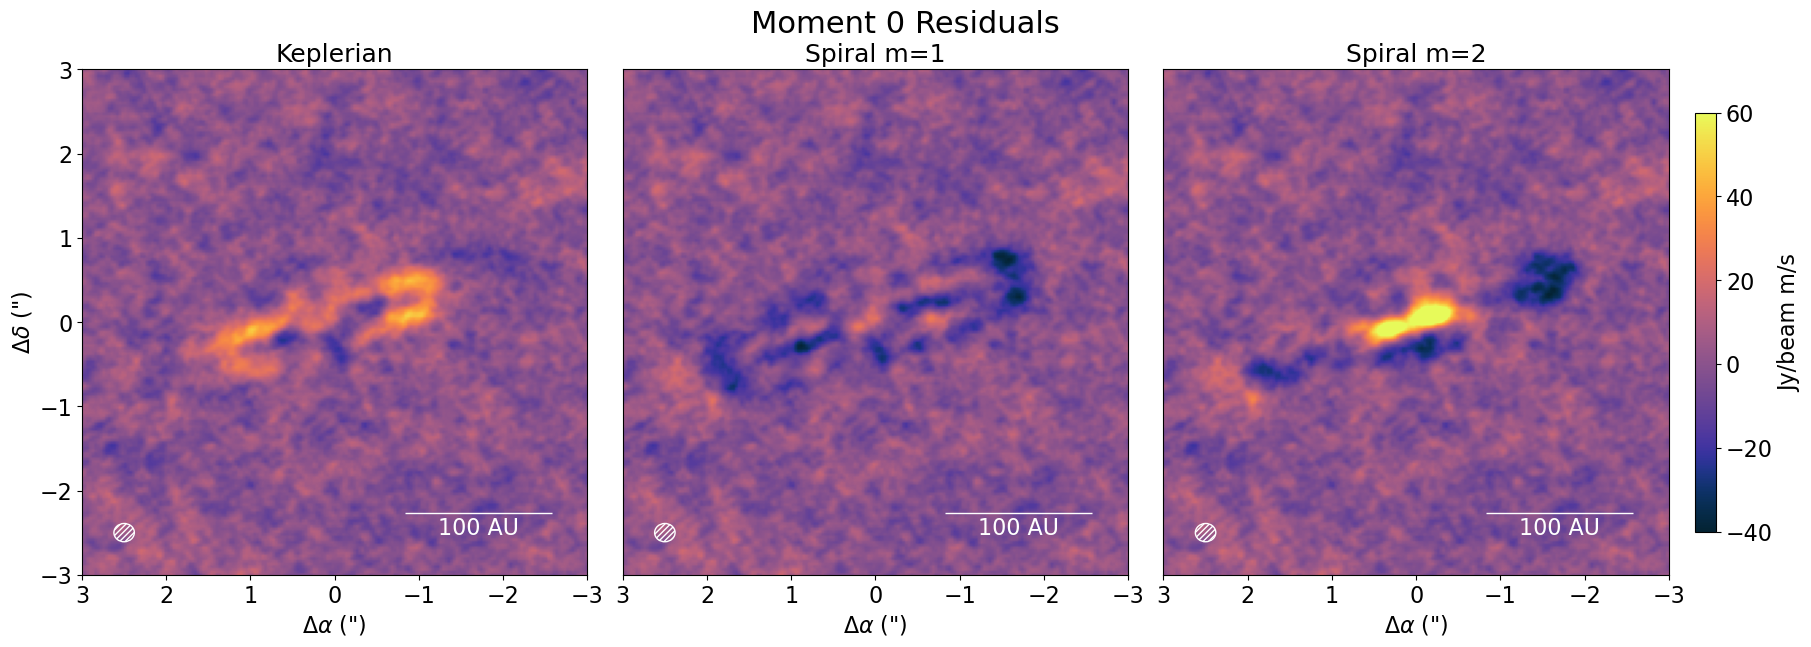

In [15]:

# Load images and WCS (reuse from earlier cells if possible)
data_fits  = fits.open('../dmr_plots/12CO_LSRK_cleanimage_M0.fits')
#model_fits = fits.open('m1spiral_model_3-31_M0.fits')
#resid_fits = fits.open('m1spiral_resids_3-31_M0.fits')

data_image  = data_fits['PRIMARY'].data
#model_image = model_fits['PRIMARY'].data
#resid_image = resid_fits['PRIMARY'].data

wcs = WCS(data_fits['PRIMARY'].header)  # Use data WCS for all (assuming shared)
header = data_fits['PRIMARY'].header

# Compute extent using the 2-arg function (from Cell 6)
extent_data = wcs_extent(data_image, wcs)
# Note: Using extent_data for all to keep offsets consistent; adjust if needed

# Beam parameters from header (in degrees)
bmaj_deg = header['BMAJ']  # Major axis
bmin_deg = header['BMIN']  # Minor axis
bpa_deg  = header['BPA']   # Position angle

# Convert to arcseconds (for plotting in offset coords)
bmaj_arcsec = bmaj_deg * 3600.0
bmin_arcsec = bmin_deg * 3600.0
bpa_arcsec  = bpa_deg  # Angle remains the same

# Plot 3 panels
fig = plt.figure(figsize=(18, 6), constrained_layout=True)
fig.suptitle("Moment 0 Residuals", fontsize=22, y=1.05)
gs = gridspec.GridSpec(nrows=1, ncols=3, figure=fig)

panels = [
    (kep_m0_im, 'Keplerian', -40, 60),
    (spiralm1_m0_im, 'Spiral m=1', -40, 60),
    (spiralm2_m0_im, 'Spiral m=2', -40, 60),  # Auto-scale for residuals
]

for i, (img, title, vmin, vmax) in enumerate(panels):
    ax = fig.add_subplot(gs[0, i])
    ax.set_aspect('equal')
    im = plt.imshow(img, cmap=cmocean.cm.thermal, origin="lower", extent=extent_data, vmin=vmin, vmax=vmax)
    ax.set_xlim(3, -3)
    ax.set_ylim(-3, 3)
    if i==2:
        cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02, label="Jy/beam m/s")
    plt.title(title, fontsize=18)
    ax.set_xlabel(r'$\Delta \alpha$ (")')
    

    if i==0:
        ax.set_ylabel(r'$\Delta \delta$ (")')
    else:
        ax.set_ylabel("")
        ax.set_yticks([])

    
    # Add beam as ellipse patch (centered at 0,0 offsets)
    beam = Ellipse((2.5, -2.5), width=bmin_arcsec, height=bmaj_arcsec, angle=bpa_arcsec,
                   fill=False, hatch='//////', color="white", linewidth=1)
    ax.add_patch(beam)
    # Scalebar: 100 AU at 52 pc ≈ 1.92 arcsec

    parallax = 17.4725e-3
    dist = 1/parallax

    scalelength = 100*u.au.to(u.parsec)
    theta = scalelength/dist
    theta_rad = theta*u.rad.to(u.deg)

    distance_pc = dist
    physical_size_au = 100
    distance_au = distance_pc * 206265  # 1 pc = 206265 AU
    theta_arcsec = (physical_size_au / distance_au) * 206265
    scalebar = AnchoredSizeBar(ax.transData, theta_arcsec, f'{physical_size_au} AU', 
                            loc='lower right', pad=1.5, color='white', frameon=False, 
                            size_vertical=0.01)  # Thin bar
    ax.add_artist(scalebar)

#plt.tight_layout()
plt.savefig("m0_resid_eachmodel.pdf", bbox_inches='tight')
plt.show()


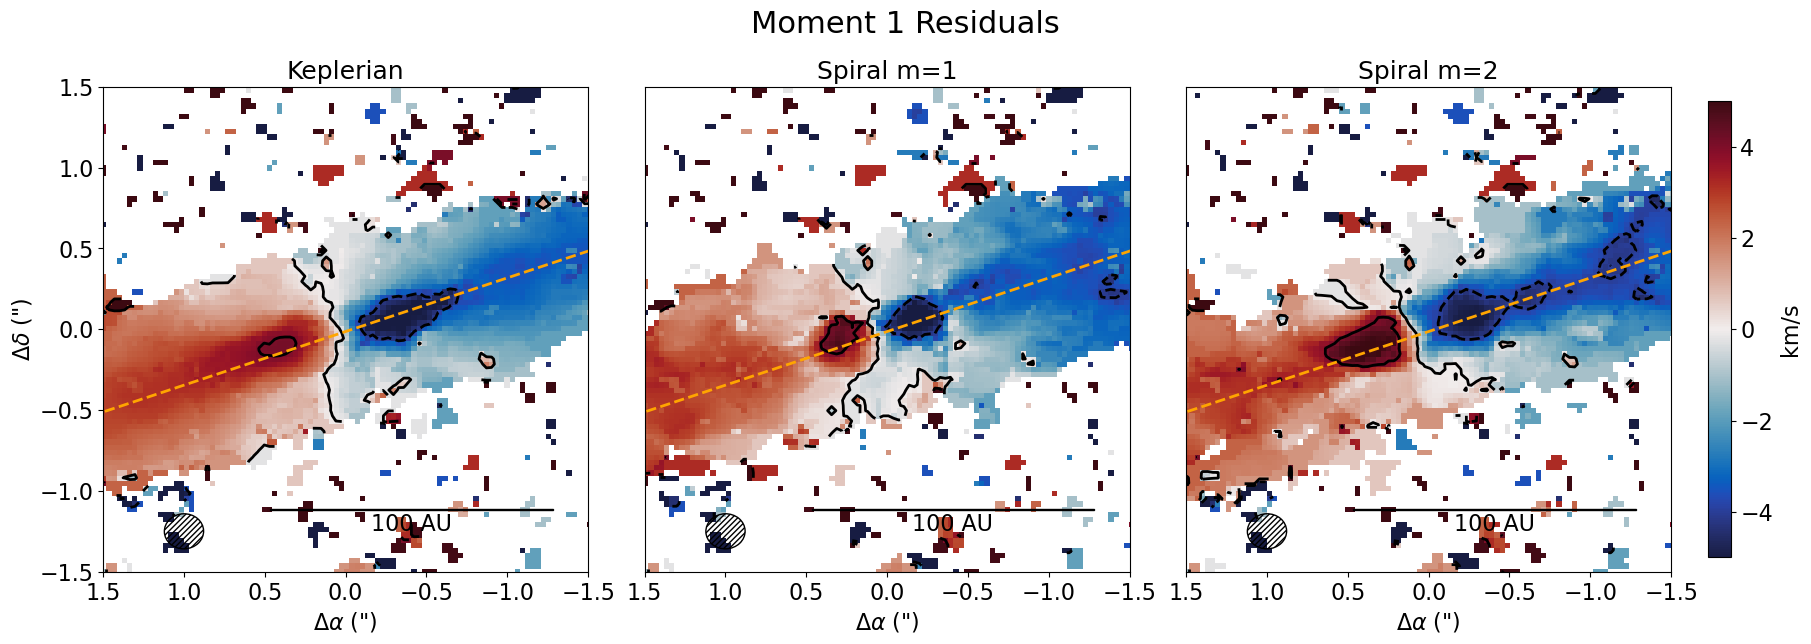

In [16]:

# Load images and WCS (reuse from earlier cells if possible)
data_fits  = fits.open('../dmr_plots/12CO_LSRK_cleanimage_M0.fits')
#model_fits = fits.open('m1spiral_model_3-31_M0.fits')
#resid_fits = fits.open('m1spiral_resids_3-31_M0.fits')

data_image  = data_fits['PRIMARY'].data
#model_image = model_fits['PRIMARY'].data
#resid_image = resid_fits['PRIMARY'].data

wcs = WCS(data_fits['PRIMARY'].header)  # Use data WCS for all (assuming shared)
header = data_fits['PRIMARY'].header

# Compute extent using the 2-arg function (from Cell 6)
extent_data = wcs_extent(data_image, wcs)
# Note: Using extent_data for all to keep offsets consistent; adjust if needed

# Beam parameters from header (in degrees)
bmaj_deg = header['BMAJ']  # Major axis
bmin_deg = header['BMIN']  # Minor axis
bpa_deg  = header['BPA']   # Position angle

# Convert to arcseconds (for plotting in offset coords)
bmaj_arcsec = bmaj_deg * 3600.0
bmin_arcsec = bmin_deg * 3600.0
bpa_arcsec  = bpa_deg  # Angle remains the same

# Plot 3 panels
fig = plt.figure(figsize=(18, 6), constrained_layout=True)
fig.suptitle("Moment 1 Residuals", fontsize=22, y=1.05)
gs = gridspec.GridSpec(nrows=1, ncols=3, figure=fig)

panels = [
    ((kep_m1_im-2780)/1000, 'Keplerian', -5, 5),
    ((spiralm1_m1_im-2780)/1000, 'Spiral m=1', -5, 5),
    ((spiralm2_m1_im-2780)/1000, 'Spiral m=2', -5, 5),  # Auto-scale for residuals
]

for i, (img, title, vmin, vmax) in enumerate(panels):
    ax = fig.add_subplot(gs[0, i])
    ax.set_aspect('equal')
    im = plt.imshow(img, cmap=cmocean.cm.balance, origin="lower", extent=extent_data, vmin=vmin, vmax=vmax)
    ax.set_xlim(1.5, -1.5)
    ax.set_ylim(-1.5, 1.5)
    if i==2:
        cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02, label="km/s")
    plt.title(title, fontsize=18)
    ax.set_xlabel(r'$\Delta \alpha$ (")')
    
    if i==0:
        ax.set_ylabel(r'$\Delta \delta$ (")')
    else:
        ax.set_ylabel("")
        ax.set_yticks([])
    
    # Add beam as ellipse patch (centered at 0,0 offsets)
    beam = Ellipse((1, -1.25), width=bmin_arcsec, height=bmaj_arcsec, angle=bpa_arcsec,
                   fill=False, hatch='//////', color="black", linewidth=1)
    ax.add_patch(beam)
    # Scalebar: 100 AU at 52 pc ≈ 1.92 arcsec

    #ax.contour(img, levels=[-0.3], colors='k', linewidths=2, origin='lower', extent=extent_data)
    #ax.contour(img, levels=[-0.1], colors='k', linewidths=2, origin='lower', extent=extent_data)
    ax.contour(img, levels=[0], colors='k', linewidths=2, origin='lower', extent=extent_data)
    ax.contour(img, levels=[4], colors='k', linewidths=2, origin='lower', extent=extent_data)
    ax.contour(img, levels=[-4], colors='k', linewidths=2, origin='lower', extent=extent_data, linestyle="solid")

    parallax = 17.4725e-3
    dist = 1/parallax

    scalelength = 100*u.au.to(u.parsec)
    theta = scalelength/dist
    theta_rad = theta*u.rad.to(u.deg)

    distance_pc = dist
    physical_size_au = 100
    distance_au = distance_pc * 206265  # 1 pc = 206265 AU
    theta_arcsec = (physical_size_au / distance_au) * 206265
    scalebar = AnchoredSizeBar(ax.transData, theta_arcsec, f'{physical_size_au} AU', 
                            loc='lower right', pad=1.5, color='black', frameon=False, 
                            size_vertical=0.01)  # Thin bar
    ax.add_artist(scalebar)

    line_x = np.array([-2.6, 2.6])
    line_y = np.array([-0.0405090874461394, -0.0405090874461394])
    trans = mtransforms.Affine2D().rotate_deg_around(+0.0780729833682188, -0.0505090874461394, 90-108.35) + ax.transData
    ax.plot(line_x, line_y, color='orange', linewidth=2, transform=trans, linestyle="--")

#plt.tight_layout()
plt.savefig("m1_resid_eachmodel.pdf", bbox_inches='tight')
plt.show()
